In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, TruncatedSVD, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [206]:
import yfinance

## Gestão de portfólio escontrando um portfolio eigen

Um dos principais objetivos de gestão de portfolio é alocar capital em diferentes clases de ativos para maximar os retornos ajustaos ao risco. 

Otimização de portfolio usando media e variancia é a tecnicas mais usada para alocação esperado dos ativos considerados. No entando, a natureza erratica dos retornos financeiros leva a erros de estimativas nessas entradas, tais erros compromentem muito a otimzalidade dos portfolios resultantes, levando a resultados ruins e instaveis.

Usando PCA, podemos pegar uma matriz de covariancia nxn de nossos ativos e criar um conj. de n portfolios principais linearmente não correlacionados.

### Definição do problema

Nosso objetivo neste estudo de caso é maximizar os retornos ajustados ao risco de um portfolio de valores mobiliários usando a PCA em um conj. de dados com retorno de ações.


In [207]:
# Dow Jone industrial Average 

# Lista oficial de tickers do Dow Jones (30 empresas)
tickers = [
    "AAPL", "MSFT", "IBM", "KO", "MCD", "NKE", "V", "GS", "JPM", "AXP",
    "BA", "CAT", "CVX", "CSCO", "DIS", "DOW", "HON", "INTC", "JNJ", "MMM",
    "MRK", "PG", "TRV", "UNH", "VZ", "WBA", "WMT", "AMGN", "CRM", "HD"
]

# Baixar os preços de fechamento ajustado
data = yfinance.download(tickers, start="2000-01-01", end="2025-08-25", auto_adjust=True)['Close']

[*********************100%***********************]  30 of 30 completed


In [208]:
data.head()

Ticker,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.840094,43.170921,32.405491,25.940285,12.610176,NaN,35.360317,16.052580,22.736227,NaN,...,25.678719,35.668083,4.523304,27.213190,17.526623,5.278116,NaN,15.844271,16.186651,14.239628
2000-01-04,0.769266,39.869869,31.181902,25.899948,12.448092,NaN,33.376526,16.052580,24.068048,NaN,...,24.776857,34.463207,4.276580,26.689566,17.294258,5.210606,NaN,15.332104,15.584527,13.706806
2000-01-05,0.780523,41.241726,30.389914,27.513641,12.739841,NaN,33.274265,16.340530,25.066927,NaN,...,25.749893,34.826591,4.523304,26.181782,17.161474,5.198332,NaN,15.844271,15.761618,13.427072
2000-01-06,0.712978,41.927670,31.009077,27.796041,13.388174,NaN,32.722095,17.036379,24.068048,NaN,...,25.963493,33.659966,4.499809,27.387737,17.493431,5.388588,NaN,15.763793,15.301164,13.573600
2000-01-07,0.746751,46.643452,31.460541,28.602905,13.825812,NaN,34.644508,17.336306,23.687536,NaN,...,28.455429,34.099827,4.499809,29.577488,18.190508,6.020736,NaN,15.647395,15.690780,14.599277


In [209]:
data.shape

(6449, 30)

<Axes: xlabel='Ticker', ylabel='Ticker'>

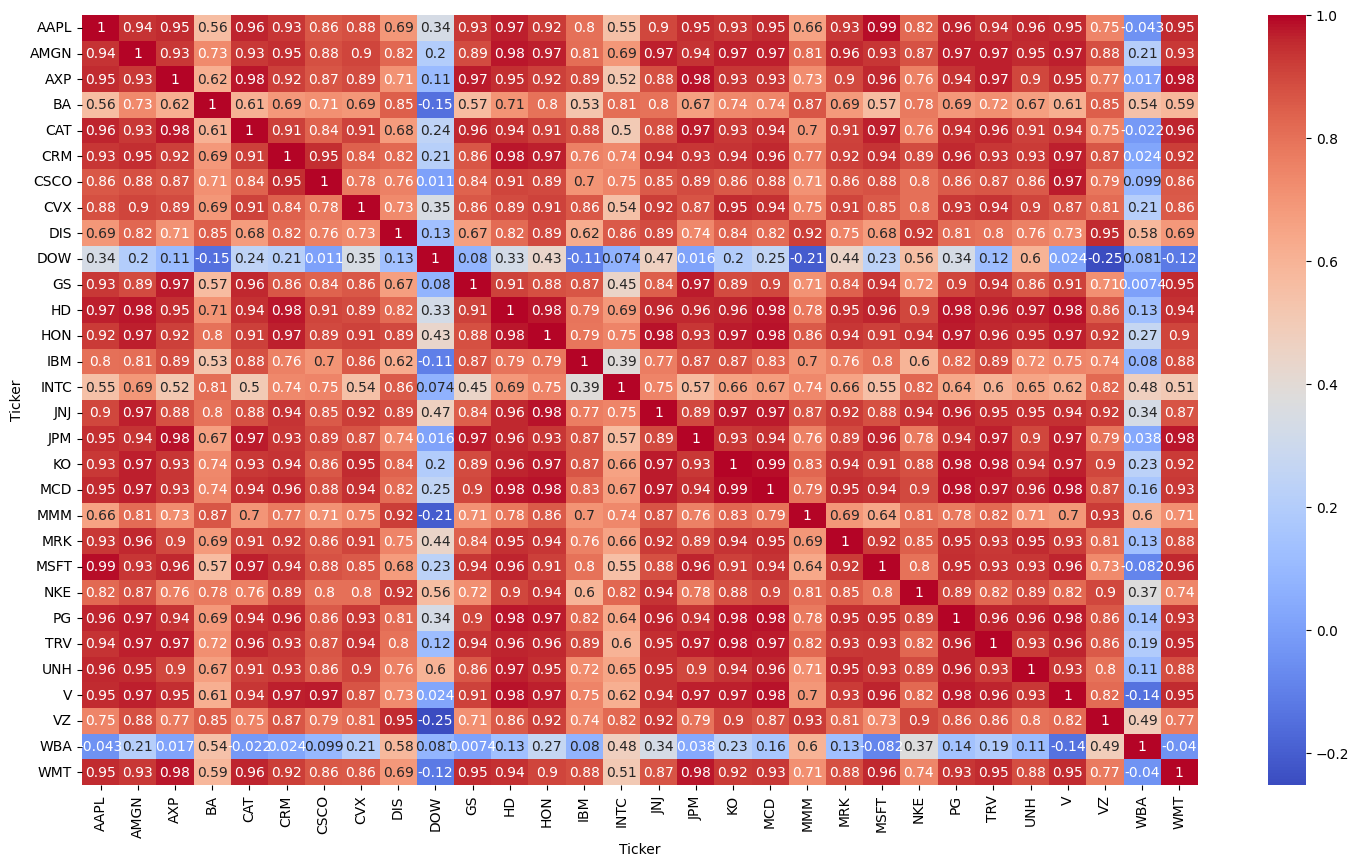

In [210]:
plt.figure(figsize=(18, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2g')

> DJIA é o indice Dow Jone Industrial e suas 30 ações respectivas

> Há um correlação positiva entre os retorno diarios.

In [211]:
# Verificando valores nulos
data.isna().sum()

Ticker
AAPL       0
AMGN       0
AXP        0
BA         0
CAT        0
CRM     1122
CSCO       0
CVX        0
DIS        0
DOW     4832
GS         0
HD         0
HON        0
IBM        0
INTC       0
JNJ        0
JPM        0
KO         0
MCD        0
MMM        0
MRK        0
MSFT       0
NKE        0
PG         0
TRV        0
UNH        0
V       2063
VZ         0
WBA        0
WMT        0
dtype: int64

In [212]:
data.isna().mean().sort_values(ascending=False)

Ticker
DOW     0.749263
V       0.319895
CRM     0.173980
AMGN    0.000000
BA      0.000000
AXP     0.000000
CAT     0.000000
CSCO    0.000000
CVX     0.000000
DIS     0.000000
GS      0.000000
HD      0.000000
HON     0.000000
AAPL    0.000000
IBM     0.000000
INTC    0.000000
JPM     0.000000
JNJ     0.000000
MCD     0.000000
MMM     0.000000
MRK     0.000000
KO      0.000000
MSFT    0.000000
NKE     0.000000
TRV     0.000000
PG      0.000000
UNH     0.000000
VZ      0.000000
WBA     0.000000
WMT     0.000000
dtype: float64

> DOW possui muito valores nulos

In [213]:
nan_percent = data.isna().mean().sort_values(ascending=False)

In [214]:
drop_columns = nan_percent[nan_percent > 0.3].index

drop_columns

Index(['DOW', 'V'], dtype='object', name='Ticker')

In [215]:
data = data.drop(drop_columns, axis=1)

In [216]:
data.shape

(6449, 28)

In [217]:
# forward fil
data = data.fillna(value=0)

Escalonando os dados, é importante usar pois caso contrario as features com valores muito alto dominariam o resultado

In [218]:
from sklearn.preprocessing import StandardScaler

StandardScaler_ = StandardScaler()
StandardScaler_.fit(data)

data_return = data.pct_change() # Retorno diario

#Remove Outliers beyong 3 standard deviation
data_return = data_return[data_return.apply(lambda x :(x-x.mean()).abs()<(3*x.std()) ).all(1)]


c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [219]:
data_std = pd.DataFrame(
    StandardScaler_.fit_transform(data),
    columns=data.columns,
    index=data.index,
)

In [220]:
data_std.head()

Ticker,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,...,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-0.684162,-0.782894,-0.684385,-0.963839,-0.883165,-0.880335,0.689023,-1.185718,-0.915815,-0.869439,...,-1.269143,-0.590975,-0.473490,-0.929485,-0.881447,-0.982213,-0.838760,-0.721671,-1.024957,-0.544362
2000-01-04,-0.685248,-0.823945,-0.703494,-0.964264,-0.884958,-0.880335,0.555743,-1.185718,-0.886435,-0.901163,...,-1.288294,-0.623632,-0.483303,-0.935561,-0.893533,-0.985986,-0.839165,-0.765705,-1.068133,-0.572408
2000-01-05,-0.685075,-0.806885,-0.715864,-0.947272,-0.881731,-0.880335,0.548873,-1.178588,-0.864400,-0.923262,...,-1.274888,-0.588397,-0.480343,-0.929485,-0.905254,-0.988143,-0.839238,-0.721671,-1.055434,-0.587132
2000-01-06,-0.686110,-0.798354,-0.706194,-0.944299,-0.874559,-0.880335,0.511775,-1.161359,-0.886435,-0.904014,...,-1.236586,-0.580663,-0.489846,-0.930063,-0.877418,-0.982752,-0.838097,-0.728590,-1.088452,-0.579419
2000-01-07,-0.685593,-0.739710,-0.699143,-0.935803,-0.869718,-0.880335,0.640932,-1.153933,-0.894829,-0.902232,...,-1.226372,-0.490428,-0.486263,-0.930063,-0.826874,-0.971431,-0.834307,-0.738597,-1.060514,-0.525432


In [221]:
data_return = data_return.dropna(axis=0)

data_std = data_std.dropna(axis=0)

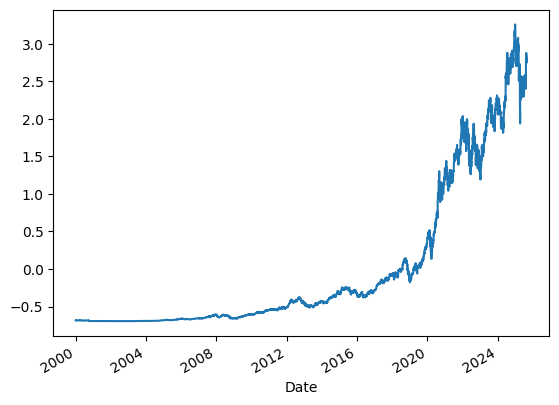

In [222]:
plt.Figure(figsize=(18, 10))
data_std['AAPL'].plot()
plt.show()

In [223]:
train_size = int(len(data_std) * 0.8)

train_data = data_std.iloc[:train_size]
test_data = data_std.iloc[train_size:]

train_data.shape, test_data.shape

((5159, 28), (1290, 28))

In [224]:
pca = PCA()

pca.fit(train_data)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


<Axes: title={'center': 'Explicando a variancai para todos fatore'}>

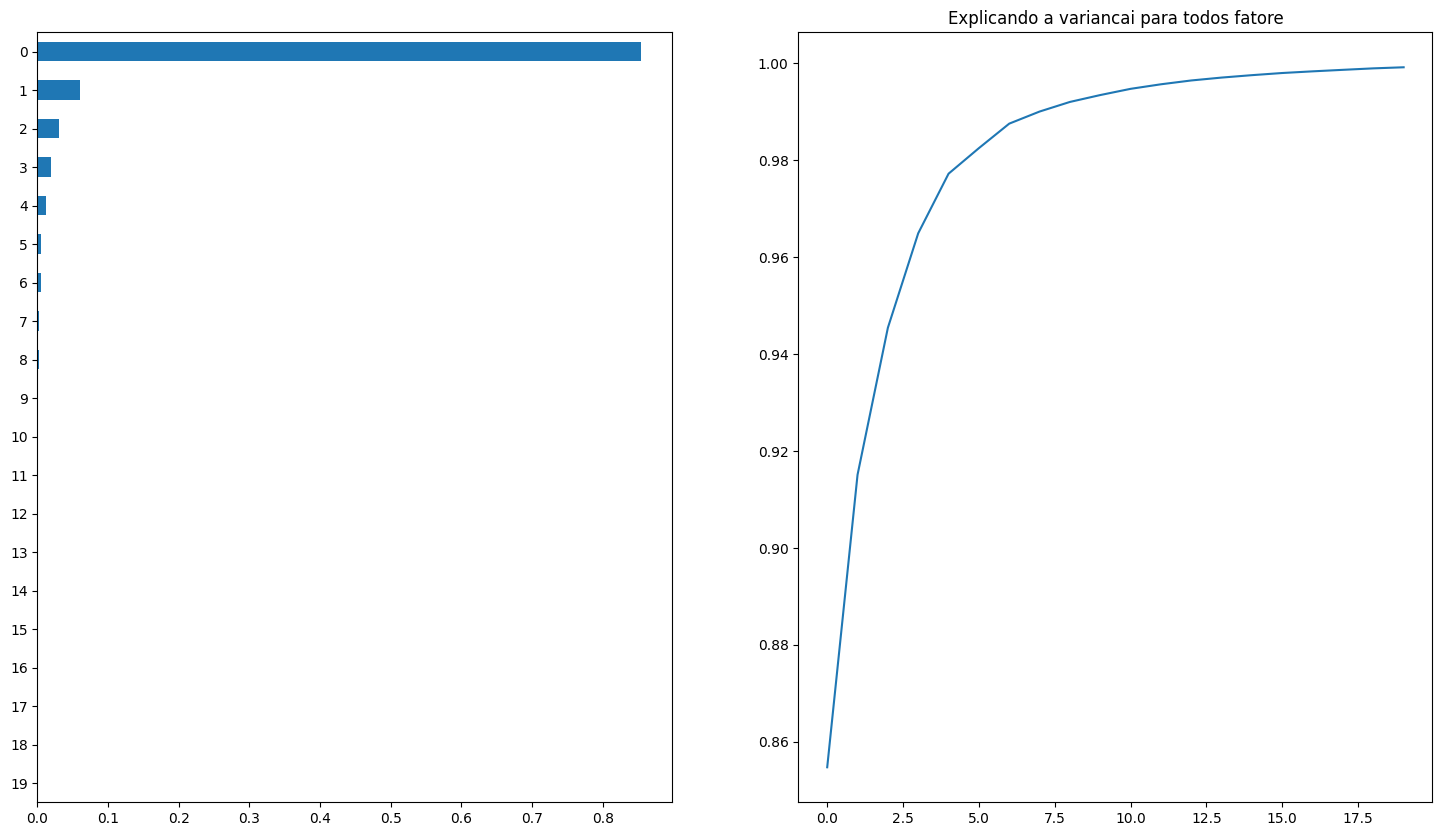

In [225]:
fig, axes = plt.subplots(figsize=(18, 10), ncols=2)

pd.Series(
    pca.explained_variance_ratio_[:20]
).sort_values().plot.barh('Explicando a variancai para top fatore', ax=axes[0])

pd.Series(
    pca.explained_variance_ratio_[:20].cumsum()
).plot(title='Explicando a variancai para todos fatore', ax=axes[1])


Agora vamos olhar mais de perto cada um dos componentes principais. Eles podem ser menos interpretaveis do que as features originais. Podemos observar os pesos dos fatores em cada componente principal para avaliar qualquer tema intuitivo com relação as 28 ações. Criamos 5 portfolios, definindo os pedos de cada ação como o primeiroo dos 5 compoenctes princiapais

In [226]:
def PCA_WEIGHT():
    weights = pd.DataFrame()

    for i in range(len(pca.components_)):
        weights[f'PC{i}'] = pca.components_[i] / sum(pca.components_[i])
    weights = weights.values.T
    return weights

In [227]:
weight = PCA_WEIGHT()

In [228]:
sum(pca.components_[0])

np.float64(5.005745375666682)

In [229]:
num_componentes = 5

topPorfolio = pd.DataFrame(
    pca.components_[:num_componentes],
    columns=data_std.columns,
)

eigen_portfolio = topPorfolio.div(topPorfolio.sum(axis=1), axis=0)
eigen_portfolio.index = [f'Portfolio {i}' for i in range(num_componentes)]
np.sqrt(pca.explained_variance_)

array([3.04725291, 0.80962126, 0.57397357, 0.4601593 , 0.36537711,
       0.23928411, 0.23432084, 0.16454483, 0.14679469, 0.12419972,
       0.11805437, 0.10091545, 0.09259706, 0.08041928, 0.07359108,
       0.06945594, 0.06101459, 0.05823412, 0.05741281, 0.04924109,
       0.04398941, 0.04204468, 0.03647375, 0.03535849, 0.03255387,
       0.02850741, 0.02639416, 0.01738639])

array([<Axes: title={'center': 'Portfolio 0'}, xlabel='Ticker'>,
       <Axes: title={'center': 'Portfolio 1'}, xlabel='Ticker'>,
       <Axes: title={'center': 'Portfolio 2'}, xlabel='Ticker'>,
       <Axes: title={'center': 'Portfolio 3'}, xlabel='Ticker'>,
       <Axes: title={'center': 'Portfolio 4'}, xlabel='Ticker'>],
      dtype=object)

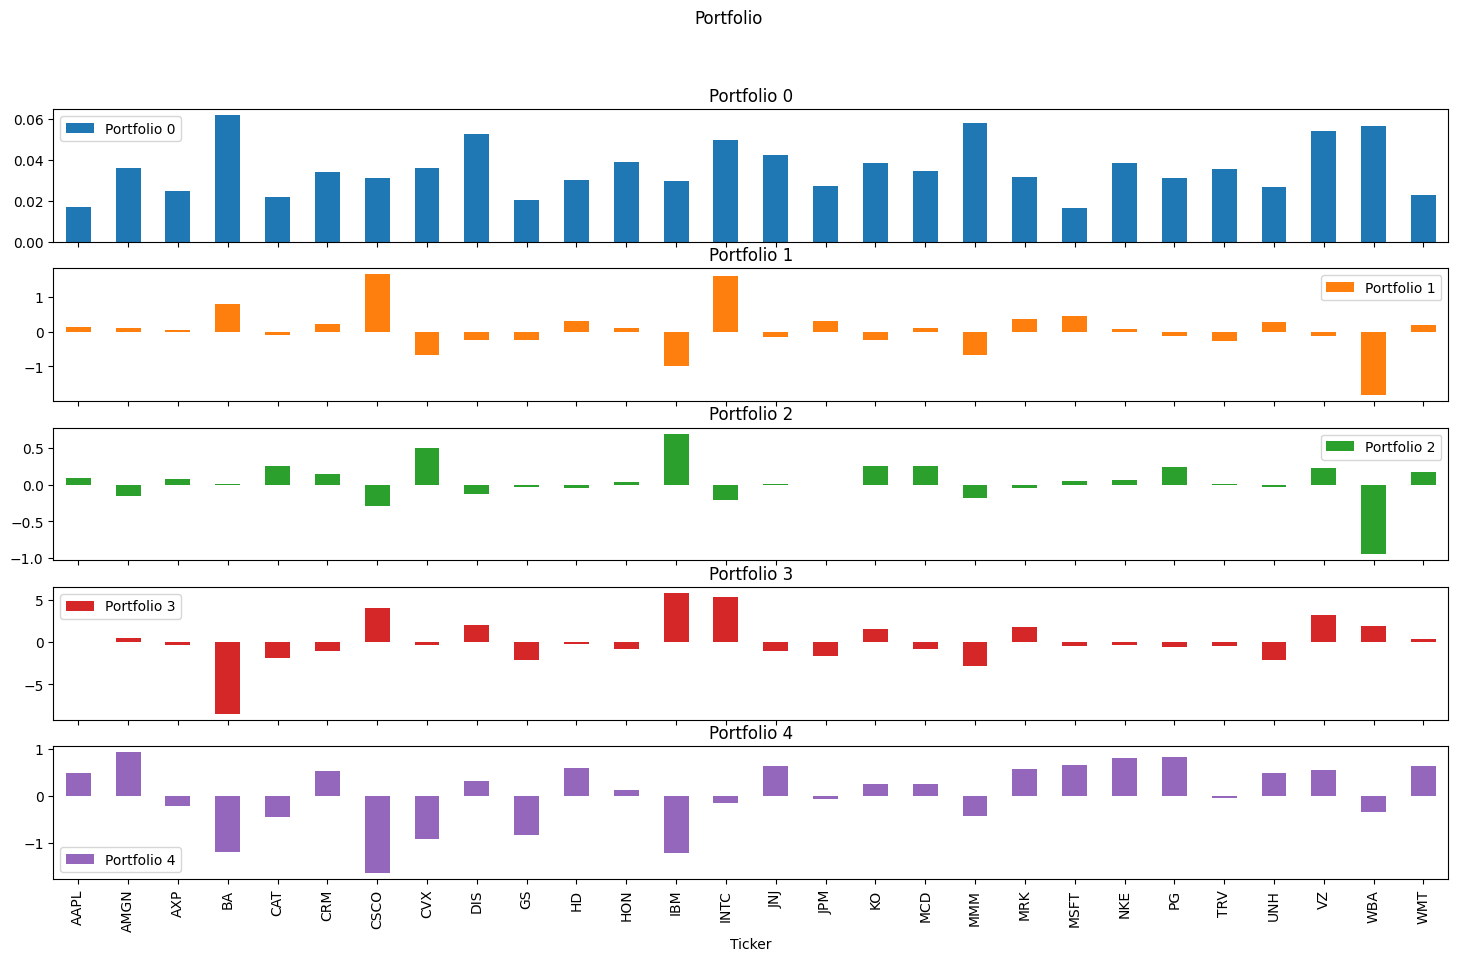

In [231]:
eigen_portfolio.T.plot.bar(subplots=True, figsize=(18, 10), title='Portfolio')

<Axes: xlabel='Ticker'>

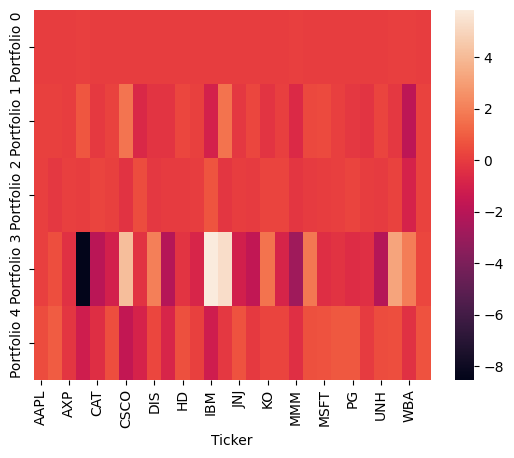

In [233]:
sns.heatmap(eigen_portfolio)